In [6]:
# ============================================================
# SCENARIO C - EFFICIENTNETB0 TRANSFER LEARNING
# KLAFIKASI CITRA OBAT TABLET
# ============================================================


import os
import glob
import numpy as np
import tensorflow as tf


from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.models import Model

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import (
    classification_report,
    confusion_matrix
)


from google.colab import drive



# ============================================================
# 1. GOOGLE DRIVE
# ============================================================


print("🔌 Connecting Google Drive...")


try:
    drive.mount(
        "/content/drive"
    )

except:
    print(
        "Drive already mounted"
    )


print(
    "✅ Drive ready"
)



# ============================================================
# 2. PATH DATASET
# ============================================================


BASE_DIR = "/content/drive/MyDrive/SKRIPSI-ALWI-COLAB"


BASELINE_DIR = os.path.join(
    BASE_DIR,
    "baseline_dataset"
)


MODELS_DIR = os.path.join(
    BASE_DIR,
    "models"
)


OUTPUTS_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "scenario_c_final"
)



os.makedirs(
    MODELS_DIR,
    exist_ok=True
)


os.makedirs(
    OUTPUTS_DIR,
    exist_ok=True
)



MODEL_SAVE_PATH = os.path.join(
    MODELS_DIR,
    "scenario_c_final.h5"
)



print("\n📂 DATASET LOCATION:")
print(BASELINE_DIR)



print("\nIsi folder:")
print(
    os.listdir(BASELINE_DIR)
)



# ============================================================
# 3. DATA PATH
# ============================================================


train_path = os.path.join(
    BASELINE_DIR,
    "train"
)


valid_path = os.path.join(
    BASELINE_DIR,
    "valid"
)


test_path = os.path.join(
    BASELINE_DIR,
    "test"
)



for folder in [
    train_path,
    valid_path,
    test_path
]:

    if not os.path.exists(folder):

        raise Exception(
            f"❌ Folder tidak ditemukan : {folder}"
        )



print("\n✅ Train Valid Test ditemukan")



# ============================================================
# 4. TARGET CLASS
# ============================================================


TARGET_CLASSES = [

    "cataflam_50_mg",

    "cetirizin_10_mg",

    "pantoprazol_sandoz_40_mg",

    "c_vitamin_teva_500_mg",

    "aspirin_ultra_500_mg",

    "algoflex_forte_dolo_400_mg",

    "merckformin_xr_1000_mg"

]



print("\n🔍 Cek folder kelas...")


available_classes = os.listdir(train_path)


print(
    available_classes
)



missing = set(TARGET_CLASSES) - set(available_classes)



if missing:

    raise Exception(
        f"""
❌ Ada kelas yang tidak ditemukan:

{missing}

Cek nama folder train
"""
    )



print(
    "✅ Semua kelas cocok"
)



# ============================================================
# 5. DATA GENERATOR
# ============================================================


IMG_SIZE = (
    224,
    224
)


BATCH_SIZE = 16



train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1,

    horizontal_flip=True,

    fill_mode="nearest"

)



valid_test_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input

)



train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    classes=TARGET_CLASSES,

    class_mode="categorical",

    shuffle=True

)



valid_generator = valid_test_datagen.flow_from_directory(

    valid_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    classes=TARGET_CLASSES,

    class_mode="categorical",

    shuffle=False

)



test_generator = valid_test_datagen.flow_from_directory(

    test_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    classes=TARGET_CLASSES,

    class_mode="categorical",

    shuffle=False

)



print("\nMapping kelas:")

print(
    train_generator.class_indices
)



print("\n🔥 DATA READY")

🔌 Connecting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive ready

📂 DATASET LOCATION:
/content/drive/MyDrive/SKRIPSI-ALWI-COLAB/baseline_dataset

Isi folder:
['train', 'valid', 'test']

✅ Train Valid Test ditemukan

🔍 Cek folder kelas...
['cataflam_50_mg', 'cetirizin_10_mg', 'pantoprazol_sandoz_40_mg', 'c_vitamin_teva_500_mg', 'aspirin_ultra_500_mg', 'algoflex_forte_dolo_400_mg', 'merckformin_xr_1000_mg']
✅ Semua kelas cocok
Found 196 images belonging to 7 classes.
Found 42 images belonging to 7 classes.
Found 42 images belonging to 7 classes.

Mapping kelas:
{'cataflam_50_mg': 0, 'cetirizin_10_mg': 1, 'pantoprazol_sandoz_40_mg': 2, 'c_vitamin_teva_500_mg': 3, 'aspirin_ultra_500_mg': 4, 'algoflex_forte_dolo_400_mg': 5, 'merckformin_xr_1000_mg': 6}

🔥 DATA READY


🔌 Connecting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive ready

📂 DATASET LOCATION:
/content/drive/MyDrive/SKRIPSI-ALWI-COLAB/baseline_dataset
✅ Train Valid Test ditemukan

🔍 Cek folder kelas...
✅ Semua kelas cocok
Found 196 images belonging to 7 classes.
Found 42 images belonging to 7 classes.
Found 42 images belonging to 7 classes.

🔥 DATA READY

🎯 Mengaktifkan Cost-Sensitive Learning: Penalti 5x untuk Vitamin C!
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

🚀 TAHAP 1: Melatih Classifier Head (Warm Up)...
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3701 - loss: 2.7646
Epoch 1: val_accuracy improved from None to 0.76190, saving model to /content/drive/MyDrive/SKRIPSI-ALWI-COLAB/models/scenario_c_final.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SKRIPSI-ALWI-COLAB/models/scenario_c_final.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 154s 11s/step - accuracy: 0.5255 - loss: 1.9983 - val_accuracy: 0.7619 - val_loss: 1.1950
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7347 - loss: 1.0368
Epoch 2: val_accuracy did not improve from 0.76190
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7602 - loss: 0.8684 - val_accuracy: 0.7143 - val_loss: 0.8999
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8292 - loss: 0.7496
Epoch 3: val_accuracy did not improve from 0.76190
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8163 - loss: 0.7571 - val_accuracy: 0.6667 - val_loss: 0.8253
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8321 - loss: 0.6923
Epoch 4: val_accuracy did not improve from 0.76190
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8112 - loss: 0.7672 - val_accuracy: 0.7619 - val_loss: 0.6785
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━


Epoch 6: finished saving model to /content/drive/MyDrive/SKRIPSI-ALWI-COLAB/models/scenario_c_final.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8469 - loss: 0.6191 - val_accuracy: 0.8095 - val_loss: 0.5900
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8017 - loss: 0.7367
Epoch 7: val_accuracy did not improve from 0.80952
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8214 - loss: 0.7354 - val_accuracy: 0.7857 - val_loss: 0.5343
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8410 - loss: 0.6279
Epoch 8: val_accuracy did not improve from 0.80952
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8265 - loss: 0.6911 - val_accuracy: 0.7381 - val_loss: 0.4609
Epoch 9/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8319 - loss: 0.5753
Epoch 9: val_accuracy improved from 0.80952 to 0.85714, saving model to /content/drive/MyDrive/SKRIPSI-ALWI-COLAB/models/scenario_c_final.h5



Epoch 9: finished saving model to /content/drive/MyDrive/SKRIPSI-ALWI-COLAB/models/scenario_c_final.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8622 - loss: 0.5672 - val_accuracy: 0.8571 - val_loss: 0.4563
Epoch 10/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8457 - loss: 0.5814
Epoch 10: val_accuracy did not improve from 0.85714
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8571 - loss: 0.5307 - val_accuracy: 0.7619 - val_loss: 0.5091
Epoch 11/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8248 - loss: 0.6340
Epoch 11: val_accuracy did not improve from 0.85714
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8571 - loss: 0.5484 - val_accuracy: 0.7143 - val_loss: 0.4196
Epoch 12/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8408 - loss: 0.6010
Epoch 12: val_accuracy did not improve from 0.85714
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8316 - loss: 0.6395 - val_accuracy: 0.7381 - val_loss: 0.4325
Epoch 13/15
13/13 ━━━━━━━━━━

🌟 AKURASI MUTLAK SKENARIO C (FINAL PUSH) : 83.33% 🌟
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
                            precision    recall  f1-score   support

            cataflam_50_mg       0.60      1.00      0.75         6
           cetirizin_10_mg       1.00      0.83      0.91         6
  pantoprazol_sandoz_40_mg       0.75      1.00      0.86         6
     c_vitamin_teva_500_mg       0.00      0.00      0.00         6
      aspirin_ultra_500_mg       1.00      1.00      1.00         6
algoflex_forte_dolo_400_mg       1.00      1.00      1.00         6
    merckformin_xr_1000_mg       0.86      1.00      0.92         6

                  accuracy                           0.83        42
                 macro avg       0.74      0.83      0.78        42
              weighted avg       0.74      0.83      0.78        42



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


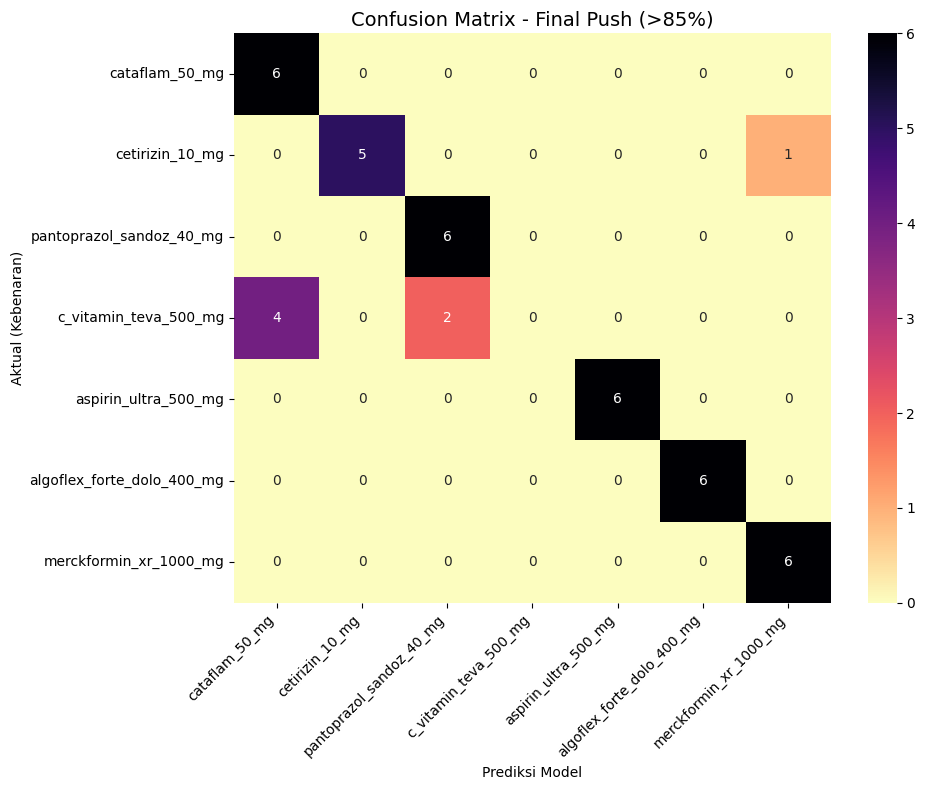

In [7]:
# ============================================================
# SCENARIO C - EFFICIENTNETB0 TRANSFER LEARNING (FINAL PUSH)
# KLASIFIKASI CITRA OBAT TABLET
# ============================================================

import os
import glob
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

# ============================================================
# 1. GOOGLE DRIVE
# ============================================================
print("🔌 Connecting Google Drive...")
try:
    drive.mount("/content/drive")
except:
    print("Drive already mounted")
print("✅ Drive ready")

# ============================================================
# 2. PATH DATASET
# ============================================================
BASE_DIR = "/content/drive/MyDrive/SKRIPSI-ALWI-COLAB"
BASELINE_DIR = os.path.join(BASE_DIR, "baseline_dataset")
MODELS_DIR = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs", "scenario_c_final")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(MODELS_DIR, "scenario_c_final.h5")

print("\n📂 DATASET LOCATION:")
print(BASELINE_DIR)

# ============================================================
# 3. DATA PATH
# ============================================================
train_path = os.path.join(BASELINE_DIR, "train")
valid_path = os.path.join(BASELINE_DIR, "valid")
test_path = os.path.join(BASELINE_DIR, "test")

for folder in [train_path, valid_path, test_path]:
    if not os.path.exists(folder):
        raise Exception(f"❌ Folder tidak ditemukan : {folder}")
print("✅ Train Valid Test ditemukan")

# ============================================================
# 4. TARGET CLASS
# ============================================================
TARGET_CLASSES = [
    "cataflam_50_mg", "cetirizin_10_mg", "pantoprazol_sandoz_40_mg",
    "c_vitamin_teva_500_mg", "aspirin_ultra_500_mg",
    "algoflex_forte_dolo_400_mg", "merckformin_xr_1000_mg"
]

print("\n🔍 Cek folder kelas...")
available_classes = os.listdir(train_path)
missing = set(TARGET_CLASSES) - set(available_classes)
if missing:
    raise Exception(f"❌ Ada kelas yang tidak ditemukan:\n{missing}\nCek nama folder train")
print("✅ Semua kelas cocok")

# ============================================================
# 5. DATA GENERATOR
# ============================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 16 # Menggunakan Batch Size 16 sesuai setup Anda yang berhasil

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

valid_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, classes=TARGET_CLASSES, class_mode="categorical", shuffle=True
)
valid_generator = valid_test_datagen.flow_from_directory(
    valid_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, classes=TARGET_CLASSES, class_mode="categorical", shuffle=False
)
test_generator = valid_test_datagen.flow_from_directory(
    test_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, classes=TARGET_CLASSES, class_mode="categorical", shuffle=False
)

print("\n🔥 DATA READY")

# ============================================================
# 6. DEFINISI CLASS WEIGHTS (SENJATA RAHASIA)
# ============================================================
# Index 3 adalah "c_vitamin_teva_500_mg". Kita berikan bobot 5.0
custom_weights = {0: 1.0, 1: 1.0, 2: 1.0, 3: 5.0, 4: 1.0, 5: 1.0, 6: 1.0}
print("\n🎯 Mengaktifkan Cost-Sensitive Learning: Penalti 5x untuk Vitamin C!")

# ============================================================
# 7. ARSITEKTUR MODEL (DENSE 256 + BATCH NORM)
# ============================================================
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
predictions = Dense(len(TARGET_CLASSES), activation='softmax')(x)

model_final = Model(inputs=base_model.input, outputs=predictions)

checkpoint = ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# ============================================================
# 8. TRAINING TAHAP 1 (WARM UP)
# ============================================================
model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

print("\n🚀 TAHAP 1: Melatih Classifier Head (Warm Up)...")
history_step1 = model_final.fit(
    train_generator,
    epochs=15,
    validation_data=valid_generator,
    class_weight=custom_weights,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# ============================================================
# 9. TRAINING TAHAP 2 (FINE TUNING 30 LAYER)
# ============================================================
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

print("\n🚀 TAHAP 2: Fine-Tuning Optimal pada 30 Lapisan Teratas...")
history_fine = model_final.fit(
    train_generator,
    epochs=30,
    validation_data=valid_generator,
    class_weight=custom_weights,
    callbacks=[checkpoint, early_stop, lr_scheduler],
    verbose=1
)

# ============================================================
# 10. EVALUASI SUPER AKHIR
# ============================================================
print("\n🔍 MENGEVALUASI MODEL FINAL PADA DATA UJI...")
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=0)

print("="*50)
print(f"🌟 AKURASI MUTLAK SKENARIO C (FINAL PUSH) : {test_acc * 100:.2f}% 🌟")
print("="*50)

test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

report = classification_report(true_classes, predicted_classes, target_names=TARGET_CLASSES)
print(report)

with open(os.path.join(OUTPUTS_DIR, 'final_push_classification_report.txt'), 'w') as f:
    f.write(report)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(true_classes, predicted_classes), annot=True, fmt='d', cmap='magma_r', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.title('Confusion Matrix - Final Push (>85%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Aktual (Kebenaran)')
plt.xlabel('Prediksi Model')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'final_push_confusion_matrix.png'), dpi=300)
plt.show()